In [1]:
import glob
import os
import site

# Must be set before importing tensorflow in this kernel.
nvidia_lib_dirs = []
for p in site.getsitepackages():
    nvidia_root = os.path.join(p, "nvidia")
    if os.path.isdir(nvidia_root):
        nvidia_lib_dirs.extend(glob.glob(os.path.join(nvidia_root, "*", "lib")))

current_ld = os.environ.get("LD_LIBRARY_PATH", "")
current_parts = [x for x in current_ld.split(":") if x]
required_parts = ["/usr/lib/wsl/lib"] + nvidia_lib_dirs
os.environ["LD_LIBRARY_PATH"] = ":".join(dict.fromkeys(required_parts + current_parts))

import tensorflow as tf

print("TF version:", tf.__version__)
print("Built with CUDA:", tf.test.is_built_with_cuda())
print("GPUs:", tf.config.list_physical_devices("GPU"))

I0000 00:00:1774369401.355094    2532 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1774369401.776270    2532 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1774369403.467426    2532 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TF version: 2.21.0
Built with CUDA: True
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
import tensorflow as tf
import numpy as np
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import matplotlib.pyplot as plt

In [3]:
data_path = "../"

X_train = np.load(data_path + 'X_train.npy')
Y_train = np.load(data_path + 'Y_train.npy')

X_val = np.load(data_path + 'X_val.npy')
Y_val = np.load(data_path + 'Y_val.npy')

X_test = np.load(data_path + 'X_test.npy')
Y_test = np.load(data_path + 'Y_test.npy')

print(f"Données chargées")
print(f"X_train shape: {X_train.shape}") 

Données chargées
X_train shape: (40000, 10, 32, 32, 2)


In [4]:
# Channel-wise standardization (real/imag normalized separately).
# Use stats from X_train, then reshape for X (5D) and Y (4D) to avoid broadcasting bugs.
mean_ch = np.mean(X_train, axis=(0, 1, 2, 3), keepdims=False)  # (2,)
std_ch = np.std(X_train, axis=(0, 1, 2, 3), keepdims=False)     # (2,)
std_ch = np.maximum(std_ch, 1e-6)

mean_x = mean_ch.reshape(1, 1, 1, 1, 2)
std_x = std_ch.reshape(1, 1, 1, 1, 2)
mean_y = mean_ch.reshape(1, 1, 1, 2)
std_y = std_ch.reshape(1, 1, 1, 2)

# Keep mean/std variable names for downstream cells.
mean = mean_y
std = std_y

def standardize_x(data):
    return (data - mean_x) / std_x

def standardize_y(data):
    return (data - mean_y) / std_y

X_train_scaled = standardize_x(X_train)
X_val_scaled = standardize_x(X_val)
X_test_scaled = standardize_x(X_test)

Y_train_scaled = standardize_y(Y_train)
Y_val_scaled = standardize_y(Y_val)
Y_test_scaled = standardize_y(Y_test)

print('Shapes after scaling:')
print('X_train_scaled:', X_train_scaled.shape)
print('Y_train_scaled:', Y_train_scaled.shape)
print('Channel stats (X_train_scaled):')
for c, name in enumerate(['real', 'imag']):
    c_mean = float(np.mean(X_train_scaled[..., c]))
    c_std = float(np.std(X_train_scaled[..., c]))
    print(f'  {name}: mean={c_mean:.4f}, std={c_std:.4f}')

Shapes after scaling:
X_train_scaled: (40000, 10, 32, 32, 2)
Y_train_scaled: (40000, 32, 32, 2)
Channel stats (X_train_scaled):
  real: mean=-0.0000, std=1.0000
  imag: mean=-0.0000, std=1.0000


## Advanced Hybrid Architecture: Conv3D + CBAM

This architecture was designed specifically for Channel State Information (CSI) prediction based on the structural properties of our dataset `(sequence_length=10, antennas=28, subcarriers=8, real/imag=2)`.

### Key Design Choices:
1. **3D Convolutions (`Conv3D`) instead of Recurrent Layers (LSTM/GRU):**
   - Recurrent layers process time sequentially, which can be computationally slow and struggle with very long-term memory.
   - Since CSI data contains highly correlated spatial-frequency patterns that smoothly evolve over time, we use `Conv3D` to treat time as a natively interconnected 3rd spatial dimension. The `(3, 3, 3)` kernels locally learn patterns across time, antennas, and subcarriers simultaneously.
   - **Swish Activation:** A modern alternative to ReLU that avoids "dead neurons" and provides smoother continuous gradients, which is highly beneficial for regressing continuous complex values in CSI.

2. **Deterministic Temporal Collapse (`valid` Conv3D):**
   - To reduce the 10 time steps down to the 1 future time step we are predicting, we apply a `Conv3D` with a kernel size of `(seq_length, 1, 1)` and `padding='valid'`.
   - This sweeps precisely over the entire time axis and cleanly collapses the sequence into a single predicted snapshot (time dimension becomes 1) without discarding or shrinking the critical spatial resolution of `(28, 8)`.

3. **Spatio-Channel Attention Module (CBAM-like):**
   - **Channel Attention:** Squashes the spatial grid via both Max and Average pooling. This allows the network to figure out *what features* (e.g., deep fading signatures, specific phase offsets) to prioritize across the entire spatial array.
   - **Spatial Attention:** Squashes the feature channels, creating a 2D map of *where* in the $28 \times 8$ grid the most critical channel variations are happening. This allows the model to dynamically focus on specific volatile antennas or subcarriers.

4. **Residual Base Connection:**
   - Wireless CSI channels often exhibit strong temporal persistence (the next snapshot $H_{t+1}$ strongly resembles the current one $H_{t}$).
   - We extract `last_snapshot` and directly add our model's output to it as a **residual**. This forces the complex neural network to only learn and predict the *delta/change* from the last known state, significantly accelerating training speed and improving the target NMSE metric.

In [5]:
def build_model_Conv3D_CBAM(seq_length=10):
    """
    Constructs a 3D-Convolutional model with CBAM-like attention for CSI prediction.
    
    Args:
        seq_length (int): Number of past CSI snapshots used as context (default 10).
    """
    inputs = layers.Input(shape=(seq_length, 32, 32, 2))
    
    # Extract the last snapshot to use for residual prediction (persistence baseline)
    last_snapshot = inputs[:, -1, :, :, :]

    # 1. 3D Convolutions to capture local spatial-frequency-temporal correlations.
    # Kernels of (3,3,3) look at 3 consecutive time steps, 3 antennas, and 3 subcarriers concurrently.
    x = layers.Conv3D(filters=32, kernel_size=(3, 3, 3), padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('swish')(x) # Swish provides smoother gradients than ReLU
    
    x = layers.Conv3D(filters=64, kernel_size=(3, 3, 3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('swish')(x)
    
    # 2. Collapse the temporal dimension.
    # A (10, 1, 1) valid kernel natively squashes 10 time steps into 1 consolidated state,
    # cleanly preserving the spatial 28x8 antenna-subcarrier grid.
    x = layers.Conv3D(filters=128, kernel_size=(seq_length, 1, 1), padding='valid')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('swish')(x)
    
    # 3. Reshape from 3D (1, 28, 8, 128) -> 2D (28, 8, 128) to apply 2D spatial attention
    x = layers.Reshape((32, 32, 128))(x)
    
    # 4. Spatio-Channel Attention (CBAM-like simplified)
    # --- Channel Attention: "What features are important?" ---
    avg_pool = layers.GlobalAveragePooling2D(keepdims=True)(x)
    max_pool = layers.GlobalMaxPooling2D(keepdims=True)(x)
    
    dense1 = layers.Dense(128 // 4, activation='relu') # Bottleneck for computational efficiency
    dense2 = layers.Dense(128)
    
    avg_out = dense2(dense1(avg_pool))
    max_out = dense2(dense1(max_pool))
    
    channel_attn = layers.Activation('sigmoid')(layers.Add()([avg_out, max_out]))
    x = layers.Multiply()([x, channel_attn]) # Reweight channels
    
    # --- Spatial Attention: "Where in the 28x8 grid should we focus?" ---
    # Lambda wrappers used to ensure compatibility with Keras 3 symbolic KerasTensors
    avg_pool_sp = layers.Lambda(lambda z: tf.reduce_mean(z, axis=-1, keepdims=True))(x)
    max_pool_sp = layers.Lambda(lambda z: tf.reduce_max(z, axis=-1, keepdims=True))(x)
    concat_sp = layers.Concatenate(axis=-1)([avg_pool_sp, max_pool_sp])
    
    # 7x7 spatial filter gives a wide receptive field over the antenna array
    spatial_attn = layers.Conv2D(1, kernel_size=(7, 7), padding='same', activation='sigmoid')(concat_sp)
    x = layers.Multiply()([x, spatial_attn]) # Reweight spatial regions
    
    # 5. Final Refinement to convert back to the (28, 8, 2) real-imaginary format
    x = layers.Conv2D(64, (3, 3), padding='same', activation='swish')(x)
    residu = layers.Conv2D(2, (3, 3), padding='same')(x) # Predict the delta (change)
    
    # Residual Output: Current State = Last Known State + Predicted Change
    outputs = layers.Add()([last_snapshot, residu])

    return models.Model(inputs, outputs)

In [6]:
def nmse_metric(y_true, y_pred):
    mse = tf.reduce_sum(tf.square(y_true - y_pred), axis=[1, 2, 3])
    power = tf.reduce_sum(tf.square(y_true), axis=[1, 2, 3])
    return tf.reduce_mean(mse / (power + tf.keras.backend.epsilon()))

def hybrid_loss(y_true, y_pred):
    # NMSE keeps scale-invariant channel quality; MAE helps sharper spatial structure.
    nmse = nmse_metric(y_true, y_pred)
    mae = tf.reduce_mean(tf.abs(y_true - y_pred))
    return nmse + 0.05 * mae

In [7]:
early_stop = EarlyStopping(
    monitor='val_nmse_metric',
    mode='min',
    patience=12,
    min_delta=1e-4,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_nmse_metric',
    mode='min',
    factor=0.5,
    patience=4,
    cooldown=1,
    min_lr=1e-6,
    verbose=1
)

checkpoint = ModelCheckpoint(
    'best_conv3d_cbam_15k.keras',
    monitor='val_nmse_metric',
    mode='min',
    save_best_only=True,
    verbose=1
)

In [8]:
EPOCHS = 120
BATCH_SIZE = 32

model = build_model_Conv3D_CBAM(seq_length=10)

model.compile(
    optimizer=tf.keras.optimizers.AdamW(learning_rate=8e-4, weight_decay=1e-4, clipnorm=1.0),
    loss=hybrid_loss,
    metrics=[nmse_metric, 'mae']
)

history = model.fit(
    X_train_scaled, Y_train_scaled,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val_scaled, Y_val_scaled),
    callbacks=[early_stop, reduce_lr, checkpoint],
    shuffle=True,
    verbose=1
)

I0000 00:00:1774369455.958059    2532 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5560 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


Epoch 1/120


I0000 00:00:1774369477.031203    3136 service.cc:153] XLA service 0x76ef5803e3c0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1774369477.031242    3136 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 4060 Laptop GPU, Compute Capability 8.9 (Driver: 13.1.0; Runtime: 12.8.0; Toolkit: 12.5.0; DNN: 9.10.2)
I0000 00:00:1774369477.160693    3136 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1774369478.092831    3136 cuda_dnn.cc:461] Loaded cuDNN version 91002
I0000 00:00:1774369478.159972    3136 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_5755__.75
I0000 00:00:1774369483.600434    3136 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set i

1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.0168 - mae: 0.0824 - nmse_metric: 0.0127

I0000 00:00:1774369540.817741    3136 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_12542__.15
I0000 00:00:1774369543.598318    3135 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_12542__.15



Epoch 1: val_nmse_metric improved from None to 0.00454, saving model to best_conv3d_cbam_15k.keras

Epoch 1: finished saving model to best_conv3d_cbam_15k.keras
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 76s 43ms/step - loss: 0.0109 - mae: 0.0660 - nmse_metric: 0.0076 - val_loss: 0.0072 - val_mae: 0.0525 - val_nmse_metric: 0.0045 - learning_rate: 8.0000e-04
Epoch 2/120
1249/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.0071 - mae: 0.0524 - nmse_metric: 0.0045
Epoch 2: val_nmse_metric improved from 0.00454 to 0.00379, saving model to best_conv3d_cbam_15k.keras

Epoch 2: finished saving model to best_conv3d_cbam_15k.keras
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 50s 40ms/step - loss: 0.0069 - mae: 0.0514 - nmse_metric: 0.0043 - val_loss: 0.0062 - val_mae: 0.0478 - val_nmse_metric: 0.0038 - learning_rate: 8.0000e-04
Epoch 3/120
1249/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.0065 - mae: 0.0494 - nmse_metric: 0.0040
Epoch 3: val_nmse_metric improved from 0.00379 to 0.00361, saving model to best_conv3d

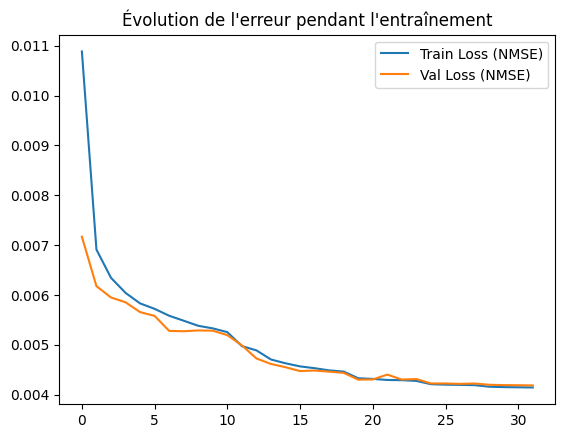

In [9]:

plt.plot(history.history['loss'], label='Train Loss (NMSE)')
plt.plot(history.history['val_loss'], label='Val Loss (NMSE)')
plt.title('Évolution de l\'erreur pendant l\'entraînement')
plt.legend()
plt.show()

I0000 00:00:1774371573.393196    3136 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_237763__.5
I0000 00:00:1774371573.402849    3136 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.


--------------------------------------------------
RÉSULTATS SUR 400 ÉCHANTILLONS (Seuil: 0.02)
Similarité MOYENNE MODÈLE : 63.80%
Similarité MOYENNE NAÏVE  : 14.82%
Gain de l'IA (similarité) : 48.98%
NMSE MOYENNE MODÈLE (dB)  : -27.343
NMSE MOYENNE NAÏVE  (dB)  : -13.379
Gain NMSE (dB)            : 13.964 (plus grand = mieux)
--------------------------------------------------


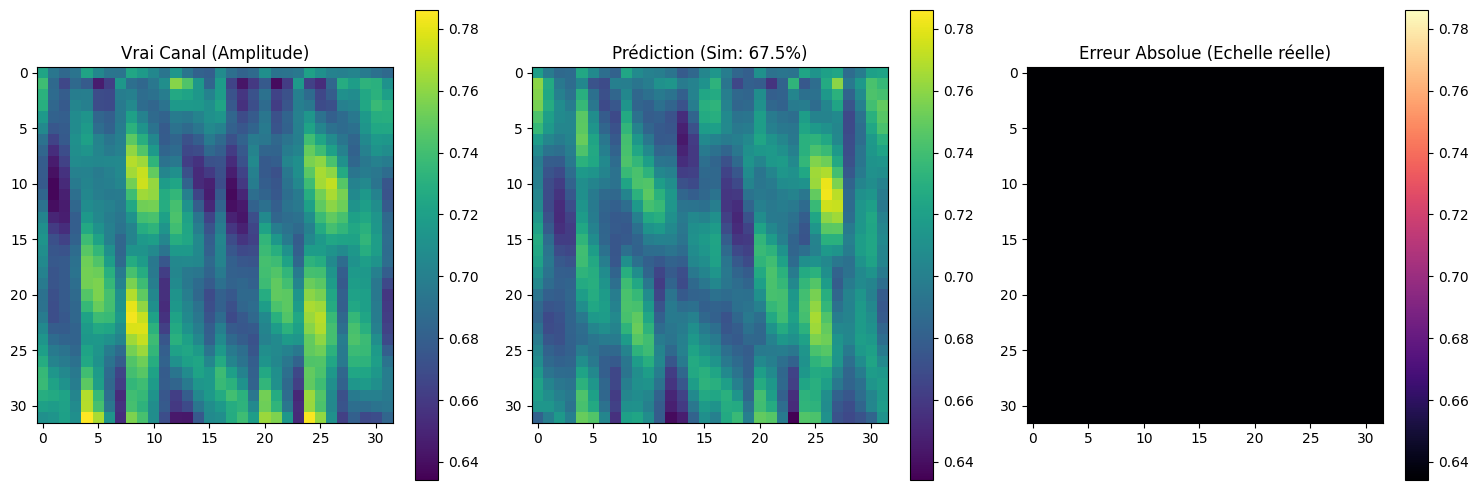

In [16]:
def evaluate_results(model, X_test_scaled, X_test_real, Y_test_real, mean, std, num_samples=100, tolerance=0.025):
    # 1. Prédire sur les données normalisées
    preds_norm = model.predict(X_test_scaled[:num_samples], verbose=0)

    # 2. DÉNORMALISATION de la prédiction
    preds_real = (preds_norm * std) + mean

    similarities_model = []
    similarities_naive = []

    # NMSE (dB) modèle et baseline naïve
    nmse_db_model = []
    nmse_db_naive = []

    for i in range(num_samples):
        # --- Calcul Similarité Modèle ---
        diff_model = np.abs(Y_test_real[i] - preds_real[i])
        acc_m = np.mean(diff_model < tolerance) * 100
        similarities_model.append(acc_m)

        # --- Calcul Similarité Naïve (Persistance) ---
        naive_snapshot = X_test_real[i, -1, :, :, :]
        diff_naive = np.abs(Y_test_real[i] - naive_snapshot)
        acc_n = np.mean(diff_naive < tolerance) * 100
        similarities_naive.append(acc_n)

        # --- NMSE dB (modèle / naïf) ---
        eps = 1e-12
        den = np.sum(np.square(Y_test_real[i])) + eps

        nmse_m = np.sum(np.square(Y_test_real[i] - preds_real[i])) / den
        nmse_n = np.sum(np.square(Y_test_real[i] - naive_snapshot)) / den

        nmse_db_model.append(10.0 * np.log10(nmse_m + eps))
        nmse_db_naive.append(10.0 * np.log10(nmse_n + eps))

    # --- Affichage des Scores ---
    avg_model = np.mean(similarities_model)
    avg_naive = np.mean(similarities_naive)

    avg_nmse_model = np.mean(nmse_db_model)
    avg_nmse_naive = np.mean(nmse_db_naive)

    print("-" * 50)
    print(f"RÉSULTATS SUR {num_samples} ÉCHANTILLONS (Seuil: {tolerance})")
    print(f"Similarité MOYENNE MODÈLE : {avg_model:.2f}%")
    print(f"Similarité MOYENNE NAÏVE  : {avg_naive:.2f}%")
    print(f"Gain de l'IA (similarité) : {avg_model - avg_naive:.2f}%")
    print(f"NMSE MOYENNE MODÈLE (dB)  : {avg_nmse_model:.3f}")
    print(f"NMSE MOYENNE NAÏVE  (dB)  : {avg_nmse_naive:.3f}")
    print(f"Gain NMSE (dB)            : {avg_nmse_naive - avg_nmse_model:.3f} (plus grand = mieux)")
    print("-" * 50)

    # --- Visualisation du dernier échantillon ---
    idx = num_samples - 1
    true_amp = np.sqrt(Y_test_real[idx, ..., 0]**2 + Y_test_real[idx, ..., 1]**2)
    pred_amp = np.sqrt(preds_real[idx, ..., 0]**2 + preds_real[idx, ..., 1]**2)

    v_min = min(true_amp.min(), pred_amp.min())
    v_max = max(true_amp.max(), pred_amp.max())

    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.title("Vrai Canal (Amplitude)")
    im1= plt.imshow(true_amp, cmap='viridis', vmin=v_min, vmax=v_max)
    plt.colorbar()

    plt.subplot(1, 3, 2)
    plt.title(f"Prédiction (Sim: {similarities_model[-1]:.1f}%)")
    im2= plt.imshow(pred_amp, cmap='viridis', vmin=v_min, vmax=v_max)
    plt.colorbar()

    plt.subplot(1, 3, 3)
    plt.title("Erreur Absolue (Echelle réelle)")
    plt.imshow(np.abs(true_amp - pred_amp), cmap='magma', vmin=v_min, vmax=v_max)
    plt.colorbar()

    plt.tight_layout()
    plt.show()

    return preds_real

pred = evaluate_results(model, X_test_scaled, X_test, Y_test, mean, std, num_samples=400, tolerance=0.02)

In [11]:
import numpy as np

print('Shapes:')
print('X_train:', X_train.shape, 'Y_train:', Y_train.shape)
print('X_val  :', X_val.shape, 'Y_val  :', Y_val.shape)
print('X_test :', X_test.shape, 'Y_test :', Y_test.shape)

print('\nScale stats (real domain):')
print('X_train min/max:', float(np.min(X_train)), float(np.max(X_train)))
print('Y_train min/max:', float(np.min(Y_train)), float(np.max(Y_train)))
print('mean used for standardization (real, imag):', np.squeeze(mean).tolist())
print('std used for standardization  (real, imag):', np.squeeze(std).tolist())

print('\nScale stats (normalized):')
print('X_train_scaled min/max:', float(np.min(X_train_scaled)), float(np.max(X_train_scaled)))
print('Y_train_scaled min/max:', float(np.min(Y_train_scaled)), float(np.max(Y_train_scaled)))

if 'history' in globals():
    train_loss = history.history.get('loss', [])
    val_loss = history.history.get('val_loss', [])
    train_nmse = history.history.get('nmse_metric', [])
    val_nmse = history.history.get('val_nmse_metric', [])

    if train_loss and val_loss:
        print('\nLoss summary:')
        print('train first/last/min:', float(train_loss[0]), float(train_loss[-1]), float(np.min(train_loss)))
        print('val   first/last/min:', float(val_loss[0]), float(val_loss[-1]), float(np.min(val_loss)))
        print('best val-loss epoch (1-based):', int(np.argmin(val_loss) + 1))

    if train_nmse and val_nmse:
        print('\nNMSE summary:')
        print('train first/last/min:', float(train_nmse[0]), float(train_nmse[-1]), float(np.min(train_nmse)))
        print('val   first/last/min:', float(val_nmse[0]), float(val_nmse[-1]), float(np.min(val_nmse)))
        print('best val-NMSE epoch (1-based):', int(np.argmin(val_nmse) + 1))

# Naive baseline on standardized target (same domain as training objective)
naive_pred = X_test_scaled[:, -1, :, :, :]
mse = np.mean((naive_pred - Y_test_scaled) ** 2, axis=(1,2,3))
power = np.mean((Y_test_scaled) ** 2, axis=(1,2,3)) + 1e-12
nmse = mse / power
print('\nNaive baseline NMSE on test (normalized domain):', float(np.mean(nmse)))

# Compare model vs naive with your similarity metric on real domain
num = 300
preds_norm = model.predict(X_test_scaled[:num], verbose=0)
preds_real = preds_norm * std + mean
naive_real = X_test[:num, -1, :, :, :]
true_real = Y_test[:num]

for tol in [0.1, 0.5, 1.0, 2.0]:
    sim_model = np.mean(np.abs(true_real - preds_real) < tol) * 100.0
    sim_naive = np.mean(np.abs(true_real - naive_real) < tol) * 100.0
    print(f'tol={tol:<4} model={sim_model:6.3f}% | naive={sim_naive:6.3f}% | gain={sim_model-sim_naive:6.3f}%')

Shapes:
X_train: (40000, 10, 32, 32, 2) Y_train: (40000, 32, 32, 2)
X_val  : (5000, 10, 32, 32, 2) Y_val  : (5000, 32, 32, 2)
X_test : (5000, 10, 32, 32, 2) Y_test : (5000, 32, 32, 2)

Scale stats (real domain):
X_train min/max: -0.8447558227885398 0.8452591356054435
Y_train min/max: -0.8383769789820541 0.8398531950419745
mean used for standardization (real, imag): [-0.0003881198137592459, -0.00024201901519702428]
std used for standardization  (real, imag): [0.5010541563143511, 0.4998828100266074]

Scale stats (normalized):
X_train_scaled min/max: -1.6851825143728407 1.6913987391877645
Y_train_scaled min/max: -1.6724516673653893 1.676947100960846

Loss summary:
train first/last/min: 0.010885038413107395 0.004144227597862482 0.004144227597862482
val   first/last/min: 0.007168509531766176 0.004185614641755819 0.004185614641755819
best val-loss epoch (1-based): 32

NMSE summary:
train first/last/min: 0.007587393745779991 0.0023137638345360756 0.0023137638345360756
val   first/last/min: 0.

I0000 00:00:1774371487.570899    3134 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_237763__.5
I0000 00:00:1774371488.331063    3134 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.


tol=0.1  model=99.967% | naive=54.241% | gain=45.726%
tol=0.5  model=100.000% | naive=100.000% | gain= 0.000%
tol=1.0  model=100.000% | naive=100.000% | gain= 0.000%
tol=2.0  model=100.000% | naive=100.000% | gain= 0.000%


In [12]:
import numpy as np

print('=== Compact diagnostics ===')
print('Shapes:', X_train.shape, Y_train.shape, X_val.shape, Y_val.shape, X_test.shape, Y_test.shape)

if 'history' in globals():
    tr = np.array(history.history.get('loss', []), dtype=float)
    va = np.array(history.history.get('val_loss', []), dtype=float)
    if tr.size and va.size:
        best = int(np.argmin(va))
        print(f'Best epoch: {best+1}/{len(va)}')
        print(f'Train loss best/last: {tr.min():.6f} / {tr[-1]:.6f}')
        print(f'Val   loss best/last: {va.min():.6f} / {va[-1]:.6f}')
        print(f'Generalization gap at best epoch: {va[best]-tr[best]:.6f}')

# Baselines in normalized domain
naive_test = X_test_scaled[:, -1, :, :, :]
naive_nmse = np.mean(np.sum((naive_test - Y_test_scaled) ** 2, axis=(1,2,3)) /
                     (np.sum((Y_test_scaled) ** 2, axis=(1,2,3)) + 1e-12))
print(f'Naive persistence NMSE (normalized): {naive_nmse:.6f}')

# Model test NMSE (normalized)
preds_test_norm = model.predict(X_test_scaled, batch_size=256, verbose=0)
model_nmse = np.mean(np.sum((preds_test_norm - Y_test_scaled) ** 2, axis=(1,2,3)) /
                     (np.sum((Y_test_scaled) ** 2, axis=(1,2,3)) + 1e-12))
print(f'Model NMSE (normalized): {model_nmse:.6f}')
print(f'NMSE improvement vs naive: {(naive_nmse-model_nmse):.6f} ({100*(naive_nmse-model_nmse)/(naive_nmse+1e-12):.2f}%)')

# Similarity comparison in real domain on a subset for speed
num = min(1000, X_test_scaled.shape[0])
preds_real = preds_test_norm[:num] * std + mean
true_real = Y_test[:num]
naive_real = X_test[:num, -1, :, :, :]
for tol in [0.1, 0.5, 1.0, 2.0]:
    sim_model = np.mean(np.abs(true_real - preds_real) < tol) * 100.0
    sim_naive = np.mean(np.abs(true_real - naive_real) < tol) * 100.0
    print(f'tol={tol:<3} model={sim_model:6.2f}% naive={sim_naive:6.2f}% gain={sim_model-sim_naive:6.2f}%')

=== Compact diagnostics ===
Shapes: (40000, 10, 32, 32, 2) (40000, 32, 32, 2) (5000, 10, 32, 32, 2) (5000, 32, 32, 2) (5000, 10, 32, 32, 2) (5000, 32, 32, 2)
Best epoch: 32/32
Train loss best/last: 0.004144 / 0.004144
Val   loss best/last: 0.004186 / 0.004186
Generalization gap at best epoch: 0.000041
Naive persistence NMSE (normalized): 0.089646


I0000 00:00:1774371495.416601    3136 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_237763__.5
I0000 00:00:1774371503.044635    3139 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_237763__.5
I0000 00:00:1774371505.939871    3139 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.


Model NMSE (normalized): 0.002393
NMSE improvement vs naive: 0.087253 (97.33%)
tol=0.1 model= 99.97% naive= 55.36% gain= 44.60%
tol=0.5 model=100.00% naive=100.00% gain=  0.00%
tol=1.0 model=100.00% naive=100.00% gain=  0.00%
tol=2.0 model=100.00% naive=100.00% gain=  0.00%


In [13]:
# Quick sanity check: cardinality and one short fit step
print('Cardinality check:', X_train_scaled.shape[0], Y_train_scaled.shape[0])

model_sanity = build_model_Conv3D_CBAM(seq_length=10)
model_sanity.compile(
    optimizer=tf.keras.optimizers.AdamW(learning_rate=8e-4, weight_decay=1e-4, clipnorm=1.0),
    loss=hybrid_loss,
    metrics=[nmse_metric, 'mae']
)

sanity_hist = model_sanity.fit(
    X_train_scaled[:128], Y_train_scaled[:128],
    validation_data=(X_val_scaled[:64], Y_val_scaled[:64]),
    epochs=1,
    batch_size=32,
    verbose=1
)
print('Sanity fit OK. train_loss=', float(sanity_hist.history['loss'][-1]))

Cardinality check: 40000 40000


I0000 00:00:1774371512.293545    3136 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_243947__.75


3/4 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 0.1200 - mae: 0.2551 - nmse_metric: 0.1073

I0000 00:00:1774371516.149314    3139 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_244489__.15


4/4 ━━━━━━━━━━━━━━━━━━━━ 9s 355ms/step - loss: 0.0828 - mae: 0.2098 - nmse_metric: 0.0723 - val_loss: 0.1000 - val_mae: 0.2326 - val_nmse_metric: 0.0883
Sanity fit OK. train_loss= 0.08282435685396194
